In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_dir = "../data"

print("Files in ../data:")
for f in os.listdir(data_dir):
    print(f)

Files in ../data:
.ipynb_checkpoints
beam_map_331F1_pol1.grd
beam_map_331F1_pol1_brad.grd


In [9]:
def load_grd(filepath):
    with open(filepath, "r") as f:
        lines = [line.rstrip("\n") for line in f]

    # Find start of structured data
    plus_idx = None
    for i, line in enumerate(lines):
        if line.startswith("++++"):
            plus_idx = i
            break
    if plus_idx is None:
        raise ValueError("Could not find ++++ header terminator.")

    # Parse core header
    ktype = int(lines[plus_idx + 1].split()[0])

    nset, icomp, ncomp, igrid = map(int, lines[plus_idx + 2].split())
    if nset != 1:
        raise ValueError(f"This reader currently expects NSET=1, got {nset}")

    ix, iy = map(int, lines[plus_idx + 3].split())
    xs, ys, xe, ye = map(float, lines[plus_idx + 4].split())
    nx, ny, klimit = map(int, lines[plus_idx + 5].split())

    if klimit != 0:
        raise ValueError(f"This reader currently expects KLIMIT=0, got {klimit}")

    # TICRA convention:
    # X = XCEN + XS + DX*(i-1)
    # Y = YCEN + YS + DY*(j-1)
    # XCEN = DX*IX, YCEN = DY*IY
    dx = (xe - xs) / (nx - 1)
    dy = (ye - ys) / (ny - 1)
    xcen = dx * ix
    ycen = dy * iy

    x = xcen + np.linspace(xs, xe, nx)
    y = ycen + np.linspace(ys, ye, ny)
    X, Y = np.meshgrid(x, y)

    # Read data block
    data_lines = lines[plus_idx + 6:]

    rows = []
    for line in data_lines:
        parts = line.split()
        if ncomp == 2 and len(parts) == 4:
            rows.append([float(v) for v in parts])
        elif ncomp == 3 and len(parts) == 6:
            rows.append([float(v) for v in parts])

    arr = np.array(rows, dtype=float)

    expected = nx * ny
    if arr.shape[0] != expected:
        raise ValueError(
            f"Expected {expected} rows of field data, found {arr.shape[0]}"
        )

    # X varies faster than Y in TICRA .grd files
    # so reshape to (ny, nx)
    F1 = (arr[:, 0] + 1j * arr[:, 1]).reshape(ny, nx)
    F2 = (arr[:, 2] + 1j * arr[:, 3]).reshape(ny, nx)

    result = {
        "ktype": ktype,
        "nset": nset,
        "icomp": icomp,
        "ncomp": ncomp,
        "igrid": igrid,
        "ix": ix,
        "iy": iy,
        "xs": xs,
        "ys": ys,
        "xe": xe,
        "ye": ye,
        "nx": nx,
        "ny": ny,
        "x": X,
        "y": Y,
        "F1": F1,
        "F2": F2,
    }

    if ncomp == 3:
        F3 = (arr[:, 4] + 1j * arr[:, 5]).reshape(ny, nx)
        result["F3"] = F3

    # Helpful aliases based on ICOMP
    if icomp == 1:
        result["component_names"] = ("E_theta", "E_phi")
        result["E_theta"] = F1
        result["E_phi"] = F2
    elif icomp == 2:
        result["component_names"] = ("E_rhc", "E_lhc")
    elif icomp == 3:
        result["component_names"] = ("E_co", "E_cx")
        result["E_co"] = F1
        result["E_cx"] = F2
        # Optional aliases if you want GUI-like names
        result["E_Lx"] = F1
        result["E_Ly"] = F2
    else:
        result["component_names"] = ("F1", "F2")

    result["power"] = np.abs(F1)**2 + np.abs(F2)**2

    return result

In [21]:
def plot_grd(filepath, field="E_co", floor_db=-60, cmap="viridis", ref_field="same"):
    d = load_grd(filepath)

    if field not in d:
        raise KeyError(f"Field '{field}' not found.")

    Z = d[field]
    mag = np.abs(Z) if np.iscomplexobj(Z) else Z

    if ref_field == "same":
        ref = np.nanmax(mag)
        ref_label = field
    else:
        if ref_field not in d:
            raise KeyError(f"Reference field '{ref_field}' not found.")
        ref_arr = d[ref_field]
        ref_mag = np.abs(ref_arr) if np.iscomplexobj(ref_arr) else ref_arr
        ref = np.nanmax(ref_mag)
        ref_label = ref_field

    if not np.isfinite(ref) or ref <= 0:
        raise ValueError(f"Bad reference value: {ref}")

    img = 20 * np.log10(np.maximum(mag / ref, 10**(floor_db / 20)))

    actual_max = np.nanmax(img)
    vmin = floor_db
    vmax = actual_max

    plt.figure(figsize=(7, 6))
    im = plt.pcolormesh(
        d["x"], d["y"], img,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    plt.xlabel("u" if d["igrid"] == 1 else "x")
    plt.ylabel("v" if d["igrid"] == 1 else "y")
    plt.title(f"{field} : {filepath.split('/')[-1]}")
    plt.colorbar(im, label=f"Magnitude [dB rel. to {ref_label}]")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

    print(f"{field} max = {actual_max:.2f} dB relative to {ref_label}")

ICOMP = 3
IGRID = 1
Components = ('E_co', 'E_cx')


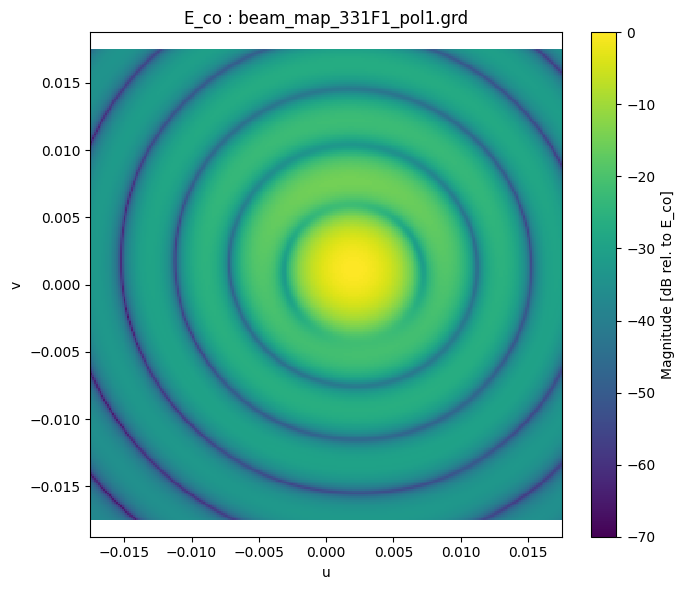

E_co max = 0.00 dB relative to E_co


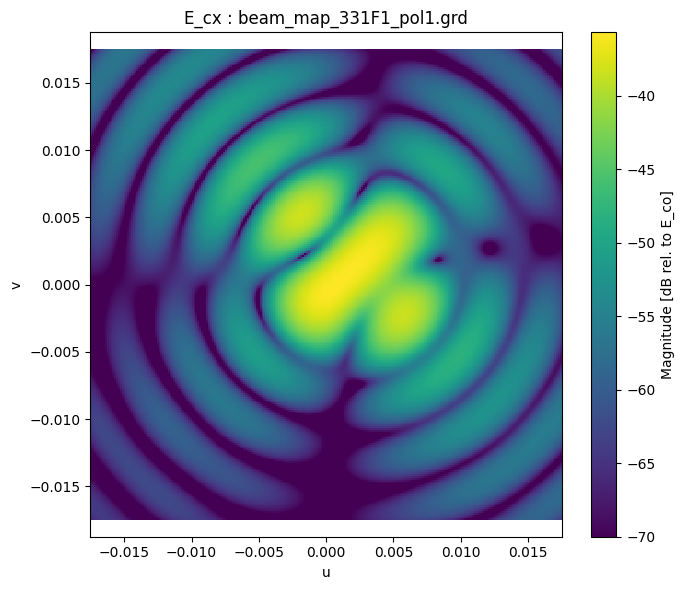

E_cx max = -35.67 dB relative to E_co


In [24]:
filepath = "../data/" + 'beam_map_331F1_pol1.grd'

d = load_grd(filepath)
print("ICOMP =", d["icomp"])
print("IGRID =", d["igrid"])
print("Components =", d["component_names"])

plot_grd(filepath, field="E_co", floor_db=-70, ref_field="E_co")
plot_grd(filepath, field="E_cx", floor_db=-70, ref_field="E_co")

ICOMP = 3
IGRID = 1
Components = ('E_co', 'E_cx')


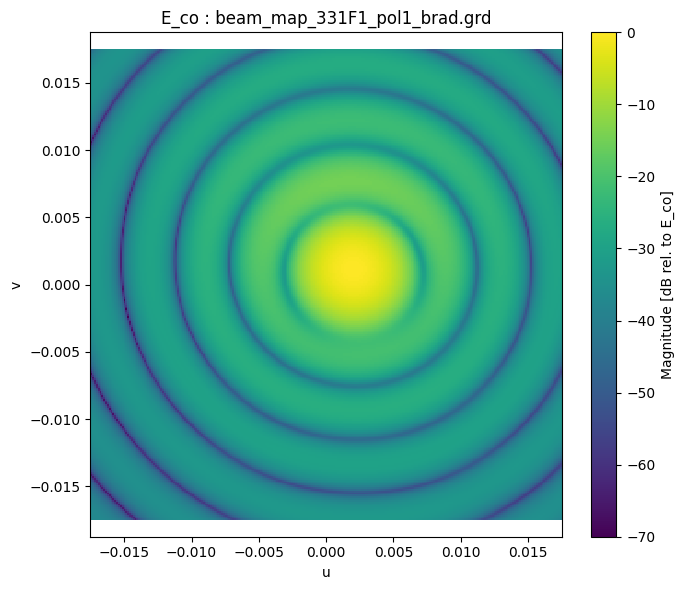

E_co max = 0.00 dB relative to E_co


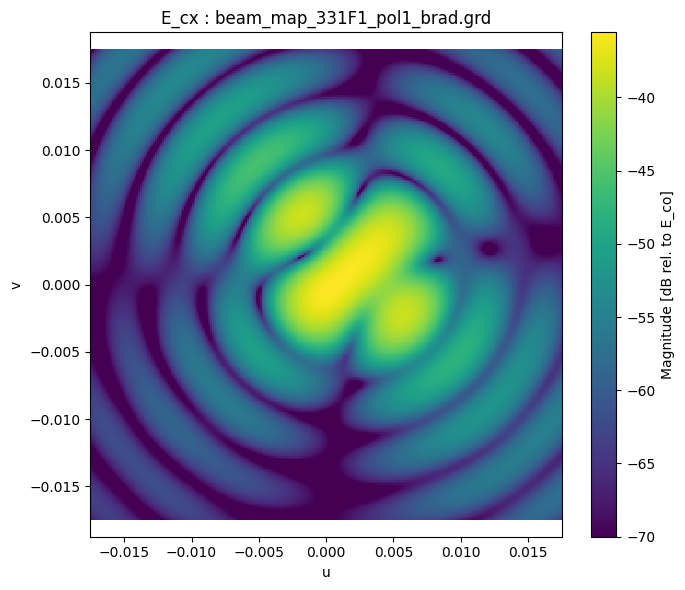

E_cx max = -35.56 dB relative to E_co


In [25]:
filepath = "../data/" + 'beam_map_331F1_pol1_brad.grd'

d = load_grd(filepath)
print("ICOMP =", d["icomp"])
print("IGRID =", d["igrid"])
print("Components =", d["component_names"])

plot_grd(filepath, field="E_co", floor_db=-70, ref_field="E_co")
plot_grd(filepath, field="E_cx", floor_db=-70, ref_field="E_co")

In [20]:
filepath = "../data/" + 'beam_map_331F1_pol1.grd'
d = load_grd(filepath)

eco_db = 20 * np.log10(np.abs(d["E_co"]) / np.max(np.abs(d["E_co"])))
ecx_db_rel_co = 20 * np.log10(np.abs(d["E_cx"]) / np.max(np.abs(d["E_co"])))

print("E_co max [dB rel co]:", np.nanmax(eco_db))
print("E_cx max [dB rel co]:", np.nanmax(ecx_db_rel_co))
print("E_cx min [dB rel co]:", np.nanmin(ecx_db_rel_co))

E_co max [dB rel co]: 0.0
E_cx max [dB rel co]: -35.6716641270925
E_cx min [dB rel co]: -105.81760870687577
